# Missing-Middle Zoning in Toronto: Affordability Under Alternative Policies
**Authors:** Chanuth Weeraratna, Devon Kisob, Kevin Kim
**Course:** SYDE 535 – Computational Simulations for SES
**Date:** April 2026

---

## ⚠️ Instructions for Running This Notebook

This notebook is **pre-run** — all figures and outputs are already embedded. You do not need to execute any cells to view the results.

---

### File Structure Required

The notebook expects the following directory structure. All required files are included in the submission zip (`ABM-Zoning-Toronto-submission.zip`):

```
ABM-Zoning-Toronto/
├── notebooks/
│   └── final_results.ipynb          ← this notebook
├── src/
│   ├── agents.py                    ← census tract agent, policy model, market update
│   ├── simulation.py                ← Monte Carlo simulation orchestrator
│   ├── visualization.py             ← plotting utilities
│   ├── calibration.py               ← ML development model (stage 1 logistic, stage 2 RF)
│   └── config.py                    ← global simulation parameters
├── data/processed/
│   ├── results_s0_final_calibration.npy   ← pre-saved N=500 simulation results (S0)
│   ├── results_s1_final_calibration.npy   ← pre-saved N=500 simulation results (S1)
│   ├── results_s2_final_calibration.npy   ← pre-saved N=500 simulation results (S2)
│   ├── results_s3_final_calibration.npy   ← pre-saved N=500 simulation results (S3)
│   ├── sensitivity_results_S0.csv         ← pre-saved OFAT sensitivity results (S0)
│   ├── sensitivity_results_S1.csv         ← pre-saved OFAT sensitivity results (S1)
│   └── ct_level_ai_change.csv             ← per-CT affordability change (spatial analysis)
└── results/figures/
    ├── heatmap_s1_vs_s0.png               ← pre-generated spatial heatmap (S1 vs S0)
    ├── heatmap_s2_vs_s0.png               ← pre-generated spatial heatmap (S2 vs S0)
    ├── sensitivity_tornado_S0.png         ← pre-generated tornado chart (S0)
    └── sensitivity_tornado_S1.png         ← pre-generated tornado chart (S1)
```

> **Note:** The `data/raw/` directory and Census shapefile are not required to run this notebook. Raw data is only needed if re-running the full data pipeline from scratch.

---

### To Re-Run on Google Colab

1. Upload `ABM-Zoning-Toronto-submission.zip` to Google Drive and extract it
2. Mount your Drive: `from google.colab import drive; drive.mount('/content/drive')`
3. Ensure the extracted folder is at `/content/drive/MyDrive/ABM-Zoning-Toronto`
   *(or update `REPO_ROOT` in Section 1 Setup to match your path)*
4. Run cells **in order from top to bottom** (`Runtime → Run all`)

### ⏱️ Runtime Warnings

| Section | Description | Estimated Time |
|---------|-------------|---------------|
| Section 1 | Setup & imports | < 1 min |
| Section 3 | Load pre-saved results + generate plots | < 1 min |
| Section 4 | Display pre-generated spatial heatmaps | < 1 min |
| Section 5 | Display pre-generated sensitivity tornado charts | < 1 min |
| **Full simulation (not run here)** | N=500 × 4 scenarios via `run_simulation.py` | ~80 min |
| **Full sensitivity analysis (not run here)** | OFAT via `scripts/sensitivity_analysis.py` | ~40 min |

---
## Section 1: Setup

In [1]:
# ── Install dependencies (only needed if running on fresh Colab instance) ──
!pip install geopandas scikit-learn matplotlib pandas numpy --quiet


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ── Path setup ──
# Detects whether the kernel CWD is the repo root or the notebooks/ subdirectory
if Path("data").exists():
    REPO_ROOT = Path(".").resolve()
elif Path("../data").exists():
    REPO_ROOT = Path("..").resolve()
else:
    # Colab: mount drive first, then set path manually
    REPO_ROOT = Path("/content/drive/MyDrive/ABM-Zoning-Toronto")

sys.path.insert(0, str(REPO_ROOT))

DATA_DIR    = REPO_ROOT / "data" / "processed"
FIGURES_DIR = REPO_ROOT / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"REPO_ROOT: {REPO_ROOT}")
print(f"DATA_DIR exists: {DATA_DIR.exists()}")

# ── Plot style ──
plt.rcParams.update({
    "font.family":       "sans-serif",
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "figure.dpi":        150,
})

SCENARIO_LABELS = {
    "S0": "S0: Status Quo",
    "S1": "S1: City-Wide Zoning",
    "S2": "S2: Transit-Targeted",
    "S3": "S3: Incentive-Based",
}
SCENARIO_COLORS = {
    "S0": "#4878CF",
    "S1": "#6ACC65",
    "S2": "#D65F5F",
    "S3": "#B47CC7",
}
T     = 40
YEARS = np.linspace(0, 10, T)

print("Setup complete.")

REPO_ROOT: /Users/Devon/Documents/ABM-Zoning-Toronto
DATA_DIR exists: True
Setup complete.


---
## Section 2: Model Overview

### 2.1 Research Question
How do alternative missing-middle zoning implementations change housing affordability across Toronto census tracts over a 10-year horizon?

### 2.2 Scenarios

| Scenario | Description | Eligible CTs | Incentive |
|----------|-------------|-------------|----------|
| **S0** | Status quo — no zoning change | 0 | None |
| **S1** | City-wide missing-middle zoning | 1,220 | None |
| **S2** | Transit-targeted zoning (within 500m of rapid transit) | 181 | None |
| **S3** | Incentive-based reform (city-wide + reduced development charges) | 1,220 | 50% boost |

### 2.3 Key Model Components

The simulation represents Toronto as **1,220 Census Tract agents**, each initialized from 2021 Statistics Canada Census data. Four pseudo-agent models govern system dynamics each quarterly time step:

1. **Demand Allocation Model** — Distributes city-wide housing demand across CTs weighted by inverse home price and transit proximity: `attractiveness = (1/home_price) × (1 + transit_indicator)`
2. **Development Model** — Two-stage ML pipeline: Stage 1 logistic regression predicts whether development occurs (CV F1=0.747); Stage 2 random forest predicts magnitude (CV R²=0.534)
3. **Market Update Model** — Updates prices and rents based on vacancy gap relative to equilibrium. Price elasticity (κ_p=2.149) and rent elasticity (κ_r=1.446) calibrated against Teranet-National Bank HPI Toronto CMA 2010–2019 (6%/yr price, 4%/yr rent)
4. **Infrastructure Model** — Tracks capacity and strain per CT; high strain penalises development probability

### 2.4 Output Metrics

- **AI_own** = median household income / home price (higher = more affordable ownership)
- **AI_rent** = median household income / annual rent (higher = more affordable renting)
- **Units added/yr** = mean new housing units added per year across all CTs

---
## Section 3: Simulation Results

Results are loaded from pre-saved N=500 Monte Carlo simulation runs. Each run used T=40 quarterly time steps (10 years), seed=42.

In [3]:
# ── Load pre-saved N=500 results ──
scenarios = ["S0", "S1", "S2", "S3"]
results = {}
for s in scenarios:
    path = DATA_DIR / f"results_{s.lower()}_final_calibration.npy"
    results[s] = np.load(path, allow_pickle=True).item()
    final_ai   = results[s]["ai_own"][:, -1].mean()
    units_yr   = results[s]["units_added"].mean()
    print(f"{s}: AI_own={final_ai:.4f}  units/yr={units_yr:.0f}")

S0: AI_own=0.0395  units/yr=0
S1: AI_own=0.0430  units/yr=5586
S2: AI_own=0.0403  units/yr=1916
S3: AI_own=0.0436  units/yr=6414


### 3.1 Summary Statistics Table

In [4]:
# ── Build summary table ──
rows = []
for s in scenarios:
    ai_own  = results[s]["ai_own"][:, -1]
    ai_rent = results[s]["ai_rent"][:, -1]
    units   = results[s]["units_added"]
    rows.append({
        "Scenario":          SCENARIO_LABELS[s],
        "Mean AI_own":       f"{ai_own.mean():.4f}",
        "Median AI_own":     f"{np.median(ai_own):.4f}",
        "Mean AI_rent":      f"{ai_rent.mean():.4f}",
        "Units added/yr":    f"{units.mean():.0f}",
        "AI_own IQR":        f"{np.percentile(ai_own,25):.4f}–{np.percentile(ai_own,75):.4f}",
    })

summary_df = pd.DataFrame(rows)
summary_df

,Scenario,Mean AI_own,Median AI_own,Mean AI_rent,Units added/yr,AI_own IQR
0,S0: Status Quo,0.0395,0.0395,2.7878,0,0.0395–0.0395
1,S1: City-Wide Zoning,0.0430,0.0430,2.9779,5586,0.0428–0.0432
2,S2: Transit-Targeted,0.0403,0.0403,2.8177,1916,0.0402–0.0404
3,S3: Incentive-Based,0.0436,0.0436,3.0067,6414,0.0434–0.0438


### 3.2 Ownership Affordability Trajectories

Saved → /Users/Devon/Documents/ABM-Zoning-Toronto/results/figures/trajectories_ai_own.png


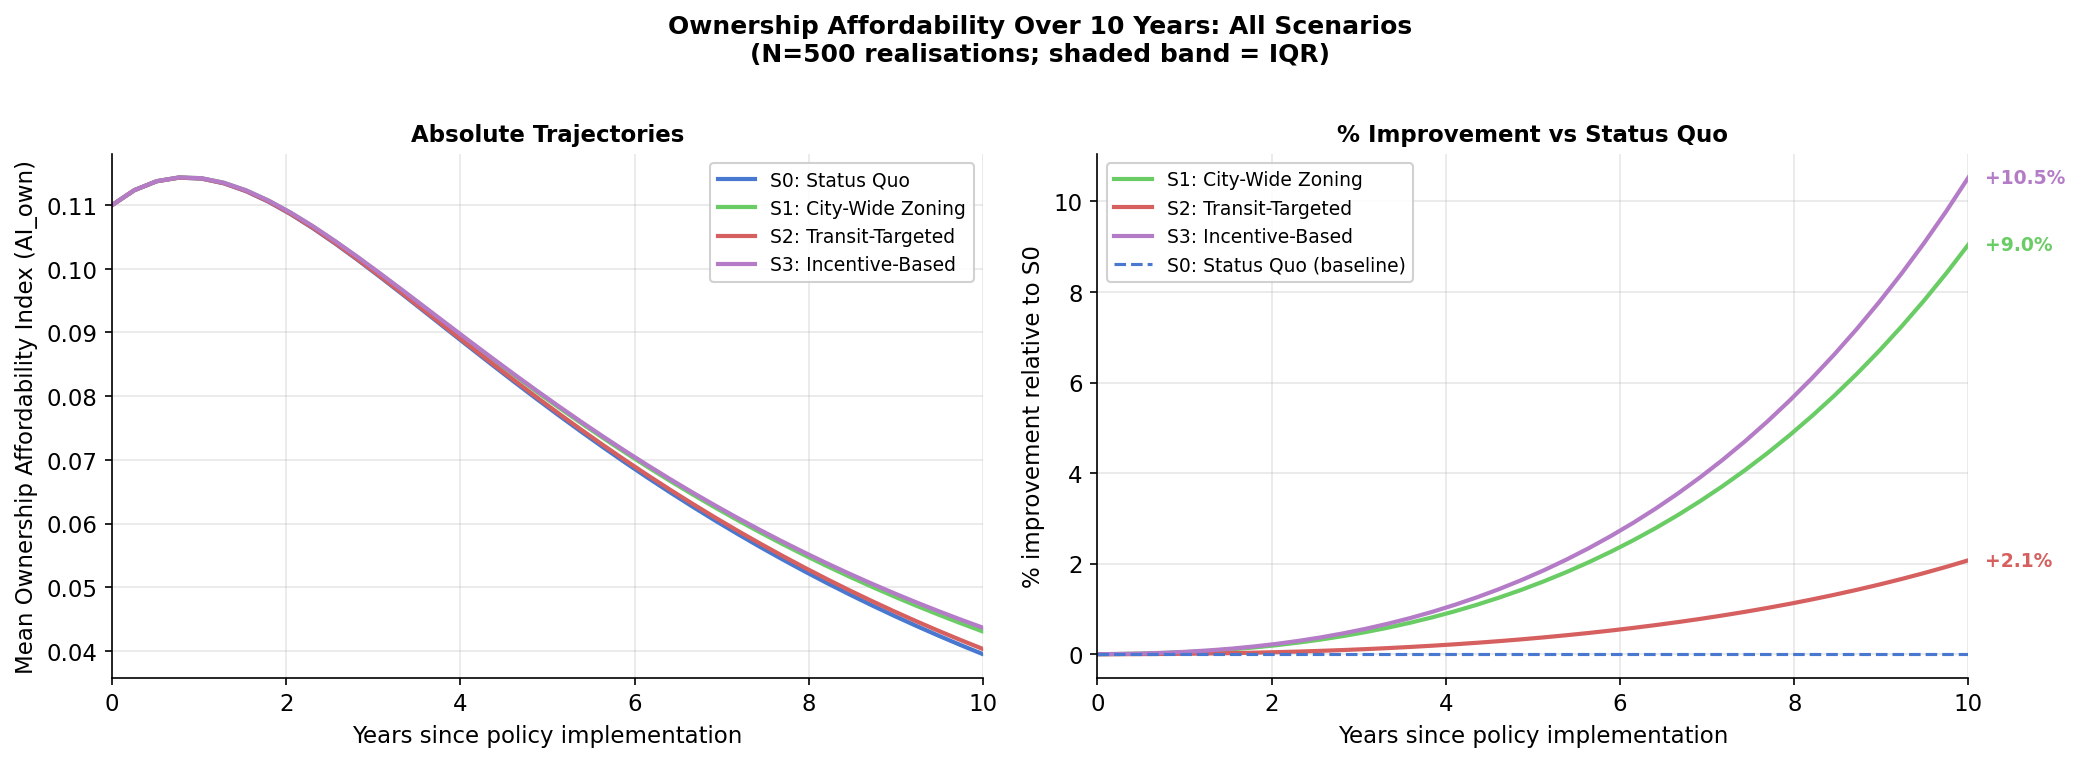

In [5]:
# ── Dual-panel trajectory plot: AI_own ──
from src.visualization import plot_all_scenarios_dual

fig = plot_all_scenarios_dual(
    results,
    metric="ai_own",
    ylabel="Mean Ownership Affordability Index (AI_own)",
    title="Ownership Affordability Over 10 Years: All Scenarios\n(N=500 realisations; shaded band = IQR)",
    save_path=FIGURES_DIR / "trajectories_ai_own.png",
)
plt.show()

### 3.3 Rental Affordability Trajectories

Saved → /Users/Devon/Documents/ABM-Zoning-Toronto/results/figures/trajectories_ai_rent.png


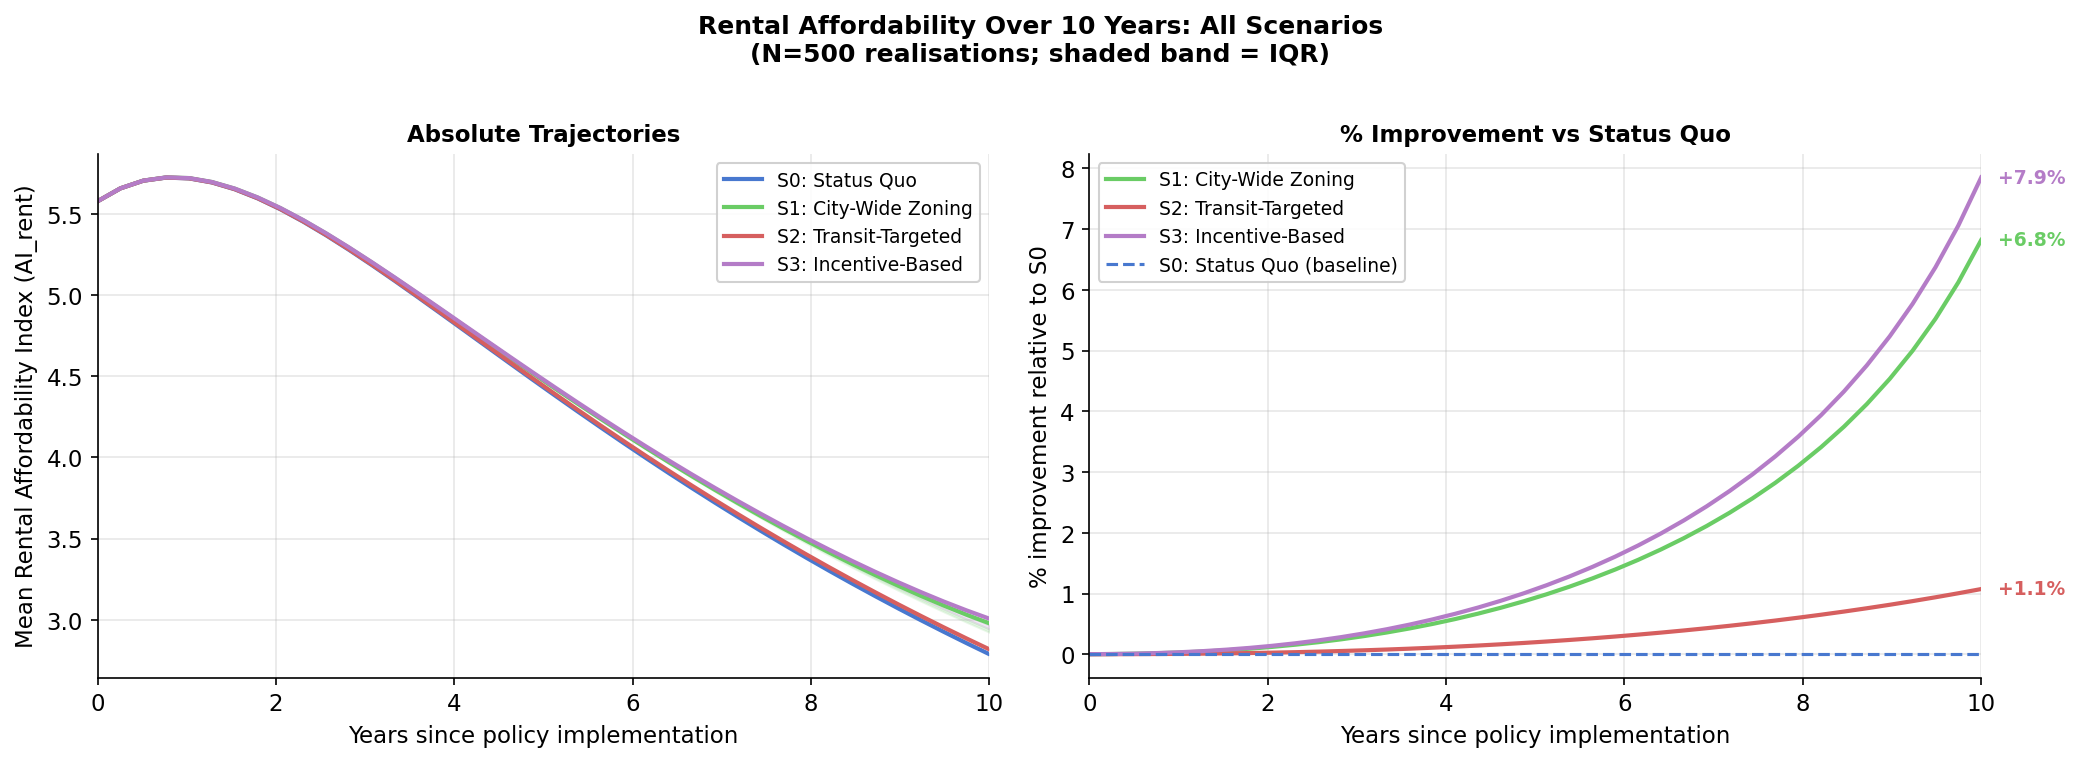

In [6]:
# ── Dual-panel trajectory plot: AI_rent ──
fig = plot_all_scenarios_dual(
    results,
    metric="ai_rent",
    ylabel="Mean Rental Affordability Index (AI_rent)",
    title="Rental Affordability Over 10 Years: All Scenarios\n(N=500 realisations; shaded band = IQR)",
    save_path=FIGURES_DIR / "trajectories_ai_rent.png",
)
plt.show()

### 3.4 Final-Year Boxplot Comparison

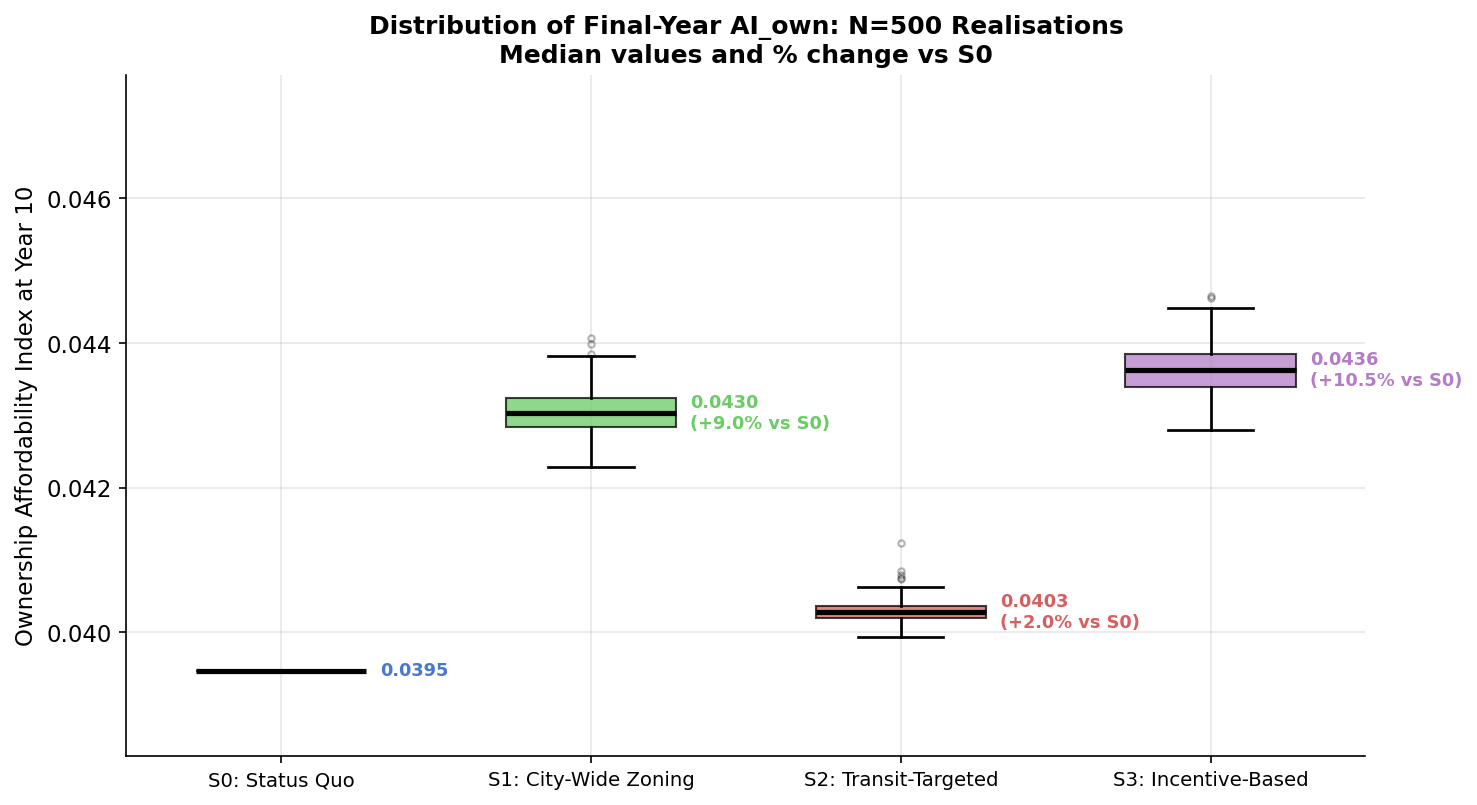

In [7]:
# ── Boxplot of final-year AI_own across scenarios ──
final_vals = [results[s]["ai_own"][:, -1] for s in scenarios]
labels     = [SCENARIO_LABELS[s] for s in scenarios]
colors     = [SCENARIO_COLORS[s] for s in scenarios]

fig, ax = plt.subplots(figsize=(10, 5.5))
bp = ax.boxplot(
    final_vals, patch_artist=True, widths=0.55,
    medianprops=dict(color="black", linewidth=2.5),
    whiskerprops=dict(linewidth=1.3),
    capprops=dict(linewidth=1.3),
    flierprops=dict(marker="o", markersize=3, alpha=0.3),
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Zoom y-axis to the data range
all_vals = np.concatenate(final_vals)
ax.set_ylim(all_vals.min() * 0.97, np.percentile(all_vals, 99) * 1.08)

# Annotate median + % vs S0
s0_med = np.median(final_vals[0])
for i, (vals, s) in enumerate(zip(final_vals, scenarios)):
    med = np.median(vals)
    pct = (med - s0_med) / s0_med * 100
    label = f"{med:.4f}"
    if s != "S0":
        label += f"\n({'+' if pct >= 0 else ''}{pct:.1f}% vs S0)"
    ax.text(i + 1.32, med, label, va="center", fontsize=8.5,
            color=colors[i], fontweight="bold")

ax.set_xticks(range(1, 5))
ax.set_xticklabels(labels, fontsize=9.5)
ax.set_ylabel("Ownership Affordability Index at Year 10")
ax.set_title("Distribution of Final-Year AI_own: N=500 Realisations\n"
             "Median values and % change vs S0",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "boxplot_ai_own_final.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.5 Housing Supply Added

/var/folders/gx/rr7g5hlj4kj3sz08wlzsbb7c0000gn/T/ipykernel_54233/37284243.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([SCENARIO_LABELS[s] for s in scenarios], fontsize=9)


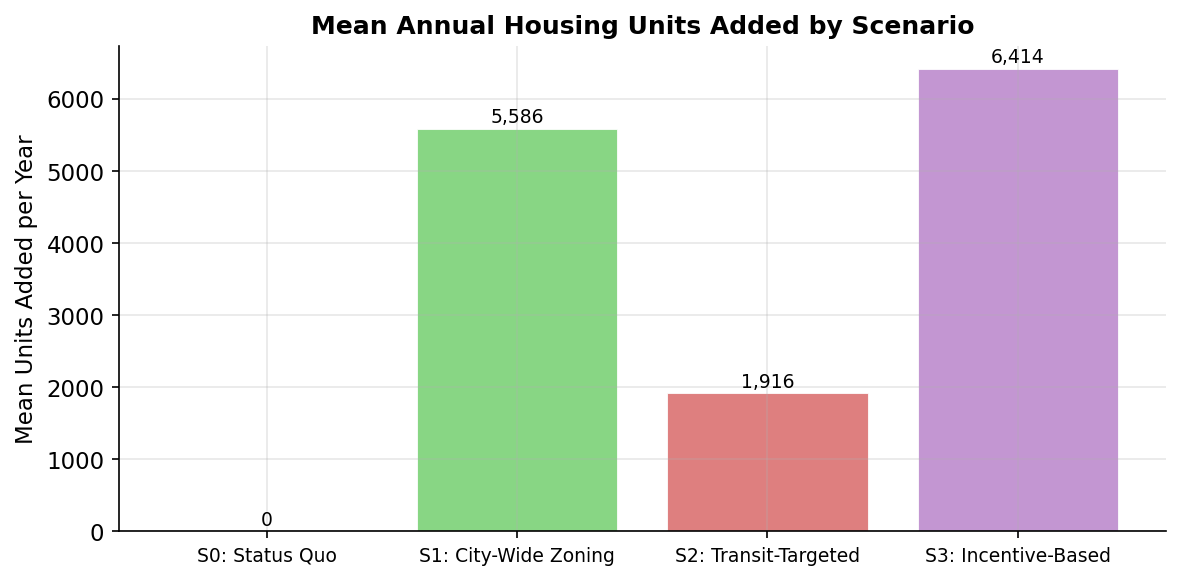

In [8]:
# ── Bar chart: mean units added per year by scenario ──
units_per_yr = {s: results[s]["units_added"].mean() for s in scenarios}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    [SCENARIO_LABELS[s] for s in scenarios],
    [units_per_yr[s] for s in scenarios],
    color=[SCENARIO_COLORS[s] for s in scenarios],
    alpha=0.8, edgecolor="white", linewidth=0.5,
)
for bar, s in zip(bars, scenarios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{units_per_yr[s]:,.0f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Mean Units Added per Year")
ax.set_title("Mean Annual Housing Units Added by Scenario",
             fontsize=12, fontweight="bold")
ax.set_xticklabels([SCENARIO_LABELS[s] for s in scenarios], fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bar_units_added.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 4: Spatial Analysis

The following maps show the per-Census Tract change in Ownership Affordability Index (AI_own) under each policy scenario relative to the S0 baseline, based on a single deterministic simulation run (seed=42).

S1 (City-Wide Zoning) vs S0 — Change in AI_own per Census Tract


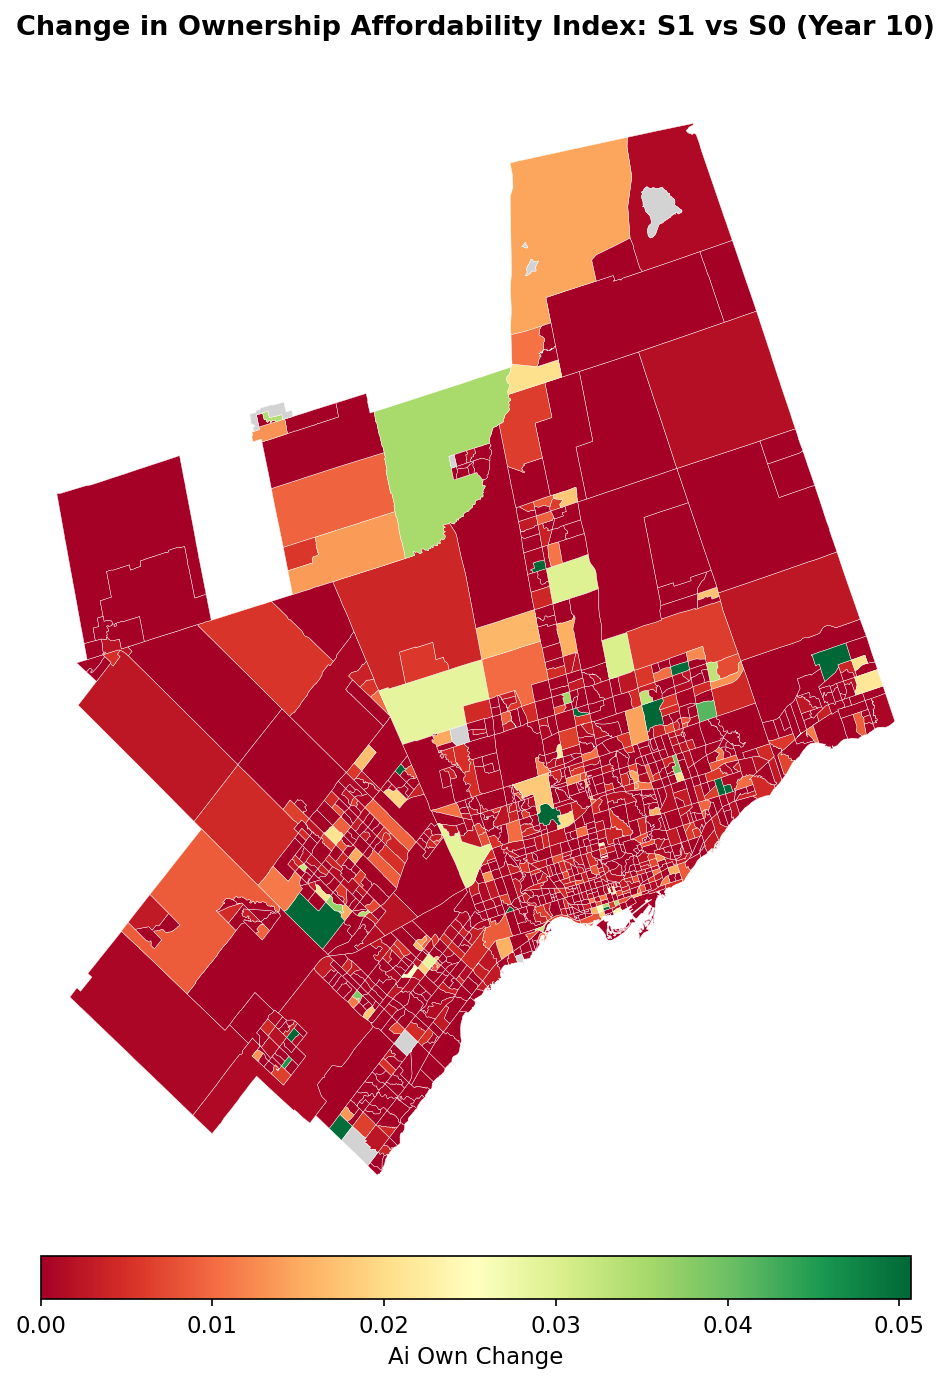

In [9]:
# ── Display pre-generated heatmaps ──
from IPython.display import Image, display

print("S1 (City-Wide Zoning) vs S0 — Change in AI_own per Census Tract")
display(Image(filename=str(FIGURES_DIR / "heatmap_s1_vs_s0.png"), width=800))

S2 (Transit-Targeted Zoning) vs S0 — Change in AI_own per Census Tract


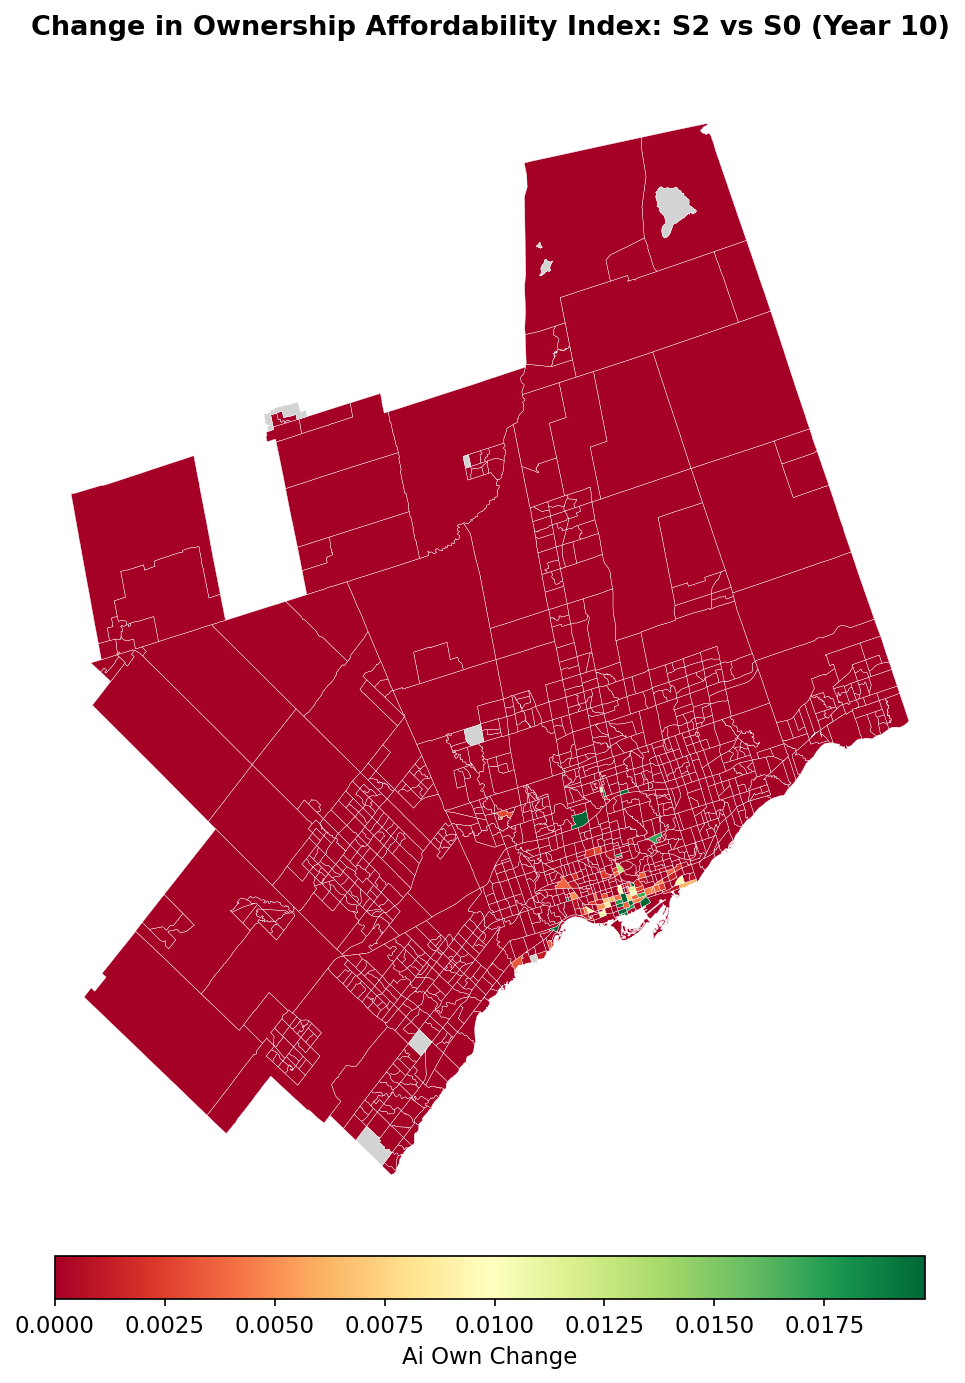

In [10]:
print("S2 (Transit-Targeted Zoning) vs S0 — Change in AI_own per Census Tract")
display(Image(filename=str(FIGURES_DIR / "heatmap_s2_vs_s0.png"), width=800))

---
## Section 5: Sensitivity Analysis

A one-factor-at-a-time (OFAT) sensitivity analysis was conducted for 7 parameters with epistemic uncertainty, using ±20% perturbation and N=20 realisations per run. The analysis was run on both S0 (no development) and S1 (city-wide zoning) to distinguish market-driven from supply-driven parameter effects.

**Parameters tested:**

| Parameter | Symbol | Baseline | Low (−20%) | High (+20%) |
|-----------|--------|----------|-----------|------------|
| Price elasticity | κ_p | 2.149 | 1.719 | 2.579 |
| Rent elasticity | κ_r | 1.446 | 1.157 | 1.735 |
| Infra baseline load | ω₀ | 0.50 | 0.40 | 0.60 |
| Infra density sensitivity | ω₁ | 0.30 | 0.24 | 0.36 |
| Base demand | — | 0.02 | 0.016 | 0.024 |
| Demand growth rate | — | 0.0025 | 0.002 | 0.003 |
| Steady-state vacancy | v_eq | 0.013 | 0.010 | 0.016 |

Tornado Chart: Scenario S0 (Baseline — No Development)


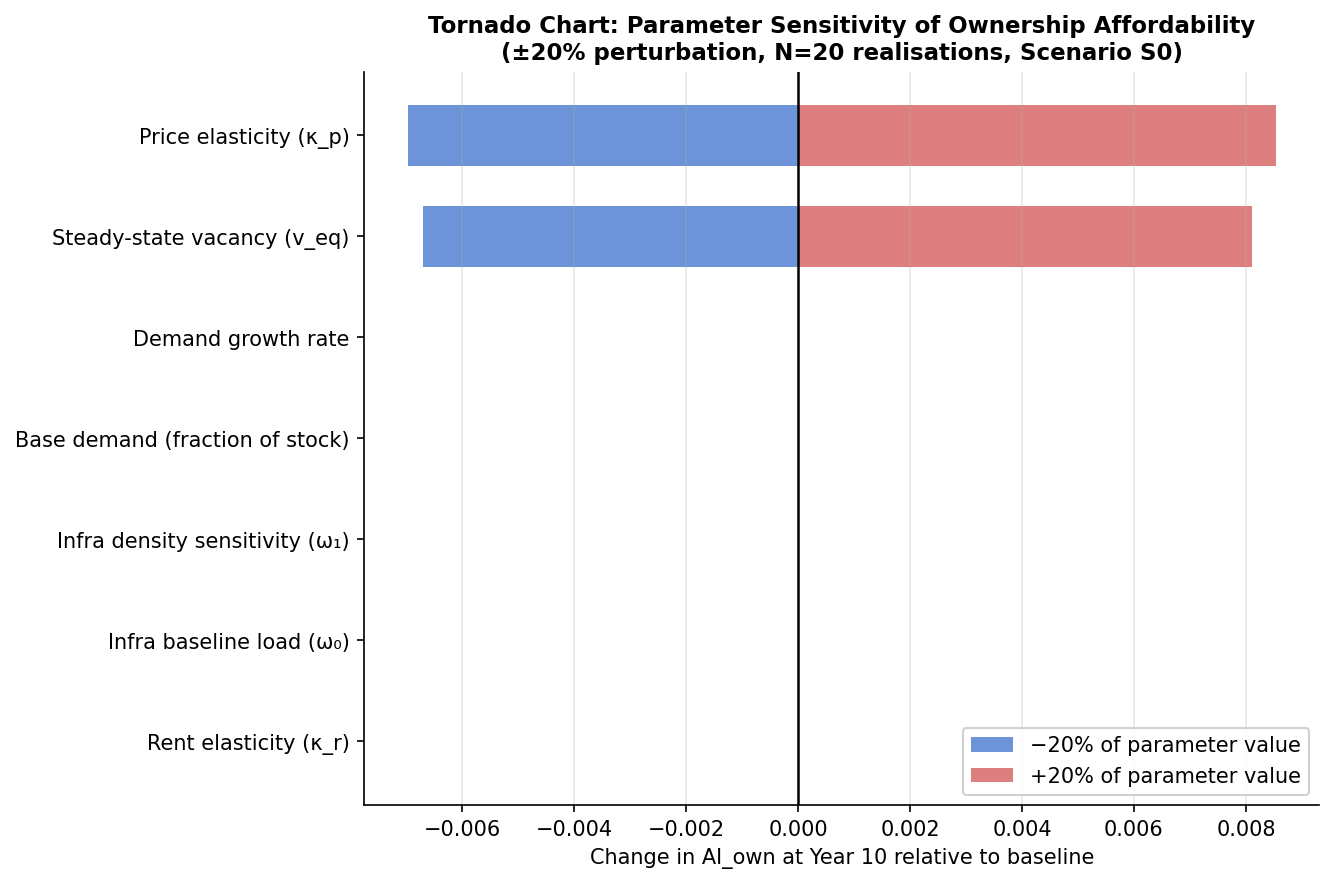

In [11]:
# ── Display pre-generated tornado charts ──
print("Tornado Chart: Scenario S0 (Baseline — No Development)")
display(Image(filename=str(FIGURES_DIR / "sensitivity_tornado_S0.png"), width=750))

Tornado Chart: Scenario S1 (City-Wide Zoning)


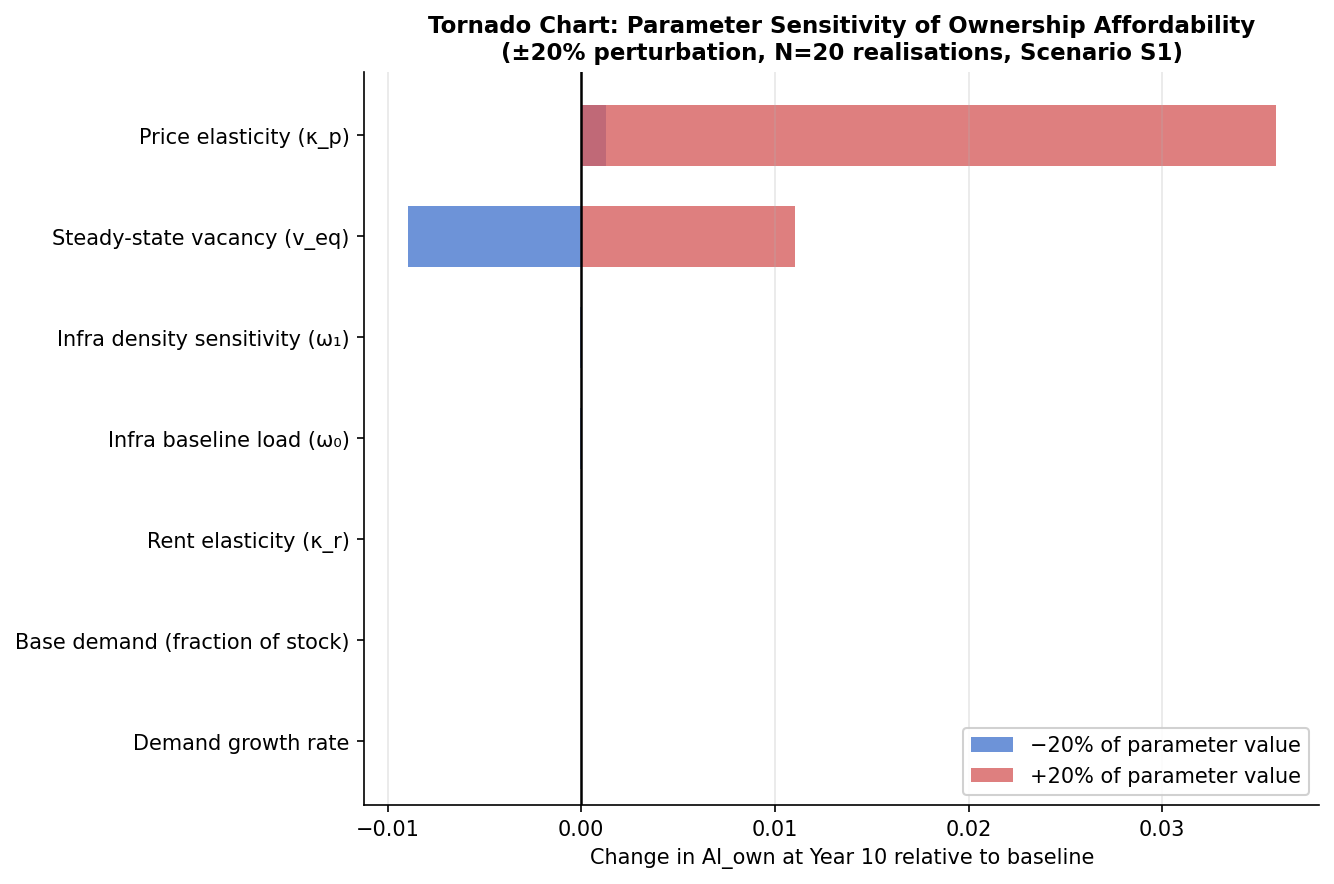

In [12]:
print("Tornado Chart: Scenario S1 (City-Wide Zoning)")
display(Image(filename=str(FIGURES_DIR / "sensitivity_tornado_S1.png"), width=750))